# K-Fold Model Evaluation

Train MLP, DT, XGBOOST, and MGBDT with 5-fold cross-validation on the updated price CSV.

## Config

Use the updated processed data directory and explicitly named CSV file. Set feature-drop options and model hyperparameters here.

In [7]:
from pathlib import Path
import os
import sys
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "house-price-regressor" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if PROJECT_ROOT.name != "house-price-regressor":
    raise RuntimeError("Run this notebook inside the house-price-regressor project.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from metrics.adjusted_r2 import adjusted_r2
from metrics.mae import mae
from metrics.mape import mape
from metrics.mse import rmse
from metrics.r2_score import r2_score
from models import TrainConfig
from models.decision_tree import DecisionTree, DecisionTreeConfig
from models.mlp import MLP, MLPConfig
from models.mgbdt_ours import MGBDTModel, mGBDTConfig


def drop_addr(df: pd.DataFrame):
    return df.drop(columns=["city", "zipcode"])


def drop_coord(df: pd.DataFrame):
    return df.drop(columns=["x", "y", "z"])


def target_encode(train_X, train_y, test_X, col, smoothing=10):
    global_mean = train_y.mean()
    tmp = train_X[[col]].copy()
    tmp["_target"] = train_y.values
    stats = tmp.groupby(col)["_target"].agg(["mean", "count"])
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (
        stats["count"] + smoothing
    )
    train_enc = train_X[col].map(smooth).fillna(global_mean)
    test_enc = test_X[col].map(smooth).fillna(global_mean)
    return train_enc, test_enc

# =========================
# Dataset / split settings
# =========================
DATA_CSV = PROJECT_ROOT / "data" / "processed" / "usa_housing_dataset_price.csv"
TARGET_NAME = "price"

DROP_ADDRESS = False
DROP_COORD = False

SEED = 42
N_SPLITS = 5
MODEL_ORDER = ["XGBOOST", "MGBDT"]

OUTPUT_DIR = PROJECT_ROOT / "test" / "k-fold" / "folded"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Feature scaling settings
# =========================
MINMAX_COLS = [
    "x", "y", "z", "condition", "age", "bedrooms",
    "bathrooms", "floors", "view",
]

ZSCORE_COLS = [
    "sqft_living", "sqft_above", "sqft_basement",
    "log_sqft_lot", "city", "zipcode",
]

# =========================
# Model hyperparameters
# =========================
DT_HPARAMS = {
    "max_depth": 6,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
}

MLP_HPARAMS = {
    "hidden_dims": [32, 32],
    "dropout": 0.0,
    "use_batch_norm": True,
    "epochs": 50,
    "lr": 1e-2,
    "batch_size": 16,
}

# XGBOOST is implemented as MGBDTModel with one XGB layer, same as the other k-fold notebooks.
XGBOOST_SOURCE_HPARAMS = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "num_boost_round": 5,
    "target_lr": 0.5,
    "epsilon": 0.3,
    "force_no_parallel": True,
    "epochs": 50,
    "batch_size": 16,
    "layer_configs": [("tp_layer", "xgb")],
}

XGBOOST_HPARAMS = dict(XGBOOST_SOURCE_HPARAMS)

# Best 2-layer candidate from experiments/mgbdt_hparam_markdown_results.md: epoch40_2L.
MGBDT_HPARAMS = {
    "learning_rate": 0.08,
    "max_depth": 4,
    "num_boost_round": 5,
    "target_lr": 0.5,
    "epsilon": 0.25,
    "force_no_parallel": True,
    "epochs": 40,
    "batch_size": 16,
    "layer_configs": [("tp_layer", "xgb"), ("tp_layer", "xgb")],
}

HPARAMS = {
    "MLP": MLP_HPARAMS,
    "DT": DT_HPARAMS,
    "XGBOOST": XGBOOST_HPARAMS,
    "MGBDT": MGBDT_HPARAMS,
}

CONFIG = {
    "project_root": str(PROJECT_ROOT),
    "data_csv": str(DATA_CSV),
    "target_name": TARGET_NAME,
    "drop_address": DROP_ADDRESS,
    "drop_coord": DROP_COORD,
    "seed": SEED,
    "n_splits": N_SPLITS,
    "model_order": MODEL_ORDER,
    "output_dir": str(OUTPUT_DIR.relative_to(PROJECT_ROOT)),
    "hparams": HPARAMS,
}

CONFIG


{'project_root': 'C:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor',
 'data_csv': 'C:\\Career\\UNIST\\4-1\\Machine Learning\\Project\\house-price-regressor\\data\\processed\\usa_housing_dataset_price.csv',
 'target_name': 'price',
 'drop_address': False,
 'drop_coord': False,
 'seed': 42,
 'n_splits': 5,
 'model_order': ['XGBOOST', 'MGBDT'],
 'output_dir': 'test\\k-fold\\folded',
 'hparams': {'MLP': {'hidden_dims': [32, 32],
   'dropout': 0.0,
   'use_batch_norm': True,
   'epochs': 50,
   'lr': 0.01,
   'batch_size': 16},
  'DT': {'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2},
  'XGBOOST': {'learning_rate': 0.1,
   'max_depth': 5,
   'num_boost_round': 5,
   'target_lr': 0.5,
   'epsilon': 0.3,
   'force_no_parallel': True,
   'epochs': 50,
   'batch_size': 16,
   'layer_configs': [('tp_layer', 'xgb')]},
  'MGBDT': {'learning_rate': 0.08,
   'max_depth': 4,
   'num_boost_round': 5,
   'target_lr': 0.5,
   'epsilon': 0.25,
   'force_no_parallel'

## Training

Run 5-fold training in the fixed order: MLP, DT, XGBOOST, then MGBDT. Each fold saves one model file under `test/k-fold/folded`.

In [8]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def existing_cols(df: pd.DataFrame, cols: list[str]) -> list[str]:
    return [col for col in cols if col in df.columns]


def split_X_y(df: pd.DataFrame, target: str):
    X = df.drop(columns=[target])
    y = df[target]
    return X, y


def preprocess_fold(X_train, X_val, y_train_fit, model_name: str):
    X_train = X_train.copy()
    X_val = X_val.copy()

    for col in ["city", "zipcode"]:
        if col in X_train.columns:
            X_train[col], X_val[col] = target_encode(X_train, y_train_fit, X_val, col)

    mm_cols = existing_cols(X_train, MINMAX_COLS)
    if mm_cols:
        scaler_mm = MinMaxScaler()
        X_train[mm_cols] = scaler_mm.fit_transform(X_train[mm_cols])
        X_val[mm_cols] = scaler_mm.transform(X_val[mm_cols])

    z_cols = existing_cols(X_train, ZSCORE_COLS)
    if z_cols:
        scaler_z = StandardScaler()
        X_train[z_cols] = scaler_z.fit_transform(X_train[z_cols])
        X_val[z_cols] = scaler_z.transform(X_val[z_cols])

    if model_name == "DT" and "age" in X_train.columns:
        X_train["age_bin"] = pd.cut(X_train["age"], bins=5, labels=[0, 1, 2, 3, 4]).astype(float)
        X_val["age_bin"] = pd.cut(X_val["age"], bins=5, labels=[0, 1, 2, 3, 4]).astype(float)

    if DROP_ADDRESS:
        X_train = drop_addr(X_train)
        X_val = drop_addr(X_val)
    if DROP_COORD:
        X_train = drop_coord(X_train)
        X_val = drop_coord(X_val)

    return X_train, X_val


def build_model(model_name: str, input_dim: int):
    if model_name == "MLP":
        hp = MLP_HPARAMS
        return MLP(
            MLPConfig(
                model="mlp",
                input_dim=input_dim,
                hidden_dims=hp["hidden_dims"],
                output_dim=1,
                dropout=hp["dropout"],
                use_batch_norm=hp["use_batch_norm"],
            )
        )

    if model_name == "DT":
        return DecisionTree(DecisionTreeConfig(model="dt", **DT_HPARAMS))

    if model_name == "XGBOOST":
        hp = XGBOOST_HPARAMS
        cfg = mGBDTConfig(
            model="mgbdt",
            input_size=input_dim,
            output_size=1,
            task="regression",
            learning_rate=hp["learning_rate"],
            max_depth=hp["max_depth"],
            num_boost_round=hp["num_boost_round"],
            target_lr=hp["target_lr"],
            epsilon=hp["epsilon"],
            force_no_parallel=hp["force_no_parallel"],
        )
        return MGBDTModel(cfg, layer_configs=hp["layer_configs"])

    if model_name == "MGBDT":
        hp = MGBDT_HPARAMS
        cfg = mGBDTConfig(
            model="mgbdt",
            input_size=input_dim,
            output_size=1,
            task="regression",
            learning_rate=hp["learning_rate"],
            max_depth=hp["max_depth"],
            num_boost_round=hp["num_boost_round"],
            target_lr=hp["target_lr"],
            epsilon=hp["epsilon"],
            force_no_parallel=hp["force_no_parallel"],
        )
        return MGBDTModel(cfg, layer_configs=hp["layer_configs"])

    raise ValueError(f"Unknown model: {model_name}")


def fit_model(model_name: str, model, X_train, y_train_fit):
    if model_name == "MLP":
        hp = MLP_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["lr"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    if model_name == "DT":
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=1, lr=0.0, batch_size=None, verbose=False)
        model.fit(cfg)
        return model

    if model_name == "XGBOOST":
        hp = XGBOOST_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["learning_rate"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    if model_name == "MGBDT":
        hp = MGBDT_HPARAMS
        cfg = TrainConfig(X=X_train, y=y_train_fit, epochs=hp["epochs"], lr=hp["learning_rate"], batch_size=hp["batch_size"], verbose=False)
        model.fit(cfg)
        return model

    raise ValueError(f"Unknown model: {model_name}")


def predict_model(model, X):
    return model.predict(X)


def model_settings_text(model_name: str, input_dim: int) -> str:
    compact = dict(HPARAMS[model_name])
    if model_name == "MGBDT":
        compact["layer_configs"] = str(compact["layer_configs"])
    compact["input_dim"] = input_dim
    return str(compact)


def metric_dict(y_true, y_pred, n_features: int):
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "R2": r2,
        "Adjusted_R2": adjusted_r2(y_true, y_pred, n_features),
    }


def save_model(model_name: str, fold: int, model):
    path = OUTPUT_DIR / f"{model_name}{fold}.pth"
    torch.save(model.state_dict(), path)
    return path


set_seed(SEED)
df = pd.read_csv(DATA_CSV)
X_all, y_all = split_X_y(df, TARGET_NAME)

print(f"DATA CSV: {DATA_CSV}")
print(f"TARGET: {TARGET_NAME}")
print(f"DROP_ADDRESS: {DROP_ADDRESS}")
print(f"DROP_COORD: {DROP_COORD}")
print(f"ROWS: {len(df)}")
print(f"RAW FEATURES: {X_all.shape[1]}")
print(f"MODEL ORDER: {MODEL_ORDER}")


DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
ROWS: 4086
RAW FEATURES: 17
MODEL ORDER: ['XGBOOST', 'MGBDT']


In [9]:
rows = []
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

for model_name in MODEL_ORDER:
    print(f"\n===== {model_name} 5-FOLD START =====")
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all), start=1):
        set_seed(SEED + fold)

        X_train_raw = X_all.iloc[train_idx].copy()
        X_val_raw = X_all.iloc[val_idx].copy()
        y_train_raw = y_all.iloc[train_idx].copy()
        y_val_raw = y_all.iloc[val_idx].copy()

        target_scaler = MinMaxScaler()
        y_train_fit = pd.Series(
            target_scaler.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel(),
            index=y_train_raw.index,
        )

        X_train, X_val = preprocess_fold(X_train_raw, X_val_raw, y_train_fit, model_name)
        input_dim = X_train.shape[1]
        model = build_model(model_name, input_dim)

        fit_start = time.perf_counter()
        model = fit_model(model_name, model, X_train, y_train_fit)
        fit_seconds = time.perf_counter() - fit_start

        pred_start = time.perf_counter()
        y_train_pred = predict_model(model, X_train)
        y_val_pred = predict_model(model, X_val)
        predict_seconds = time.perf_counter() - pred_start

        y_train_pred = target_scaler.inverse_transform(np.asarray(y_train_pred).reshape(-1, 1)).ravel()
        y_val_pred = target_scaler.inverse_transform(np.asarray(y_val_pred).reshape(-1, 1)).ravel()

        model_path = save_model(model_name, fold, model)
        settings = model_settings_text(model_name, input_dim)

        for split, y_true, y_pred in [
            ("train", y_train_raw, y_train_pred),
            ("val", y_val_raw, y_val_pred),
        ]:
            metrics = metric_dict(y_true, y_pred, input_dim)
            rows.append(
                {
                    "model": model_name,
                    "fold": fold,
                    "split": split,
                    "target": TARGET_NAME,
                    "data_csv": str(DATA_CSV.relative_to(PROJECT_ROOT)),
                    "drop_address": DROP_ADDRESS,
                    "drop_coord": DROP_COORD,
                    "n_features": input_dim,
                    "settings": settings,
                    "fit_seconds": fit_seconds,
                    "predict_seconds": predict_seconds,
                    "model_path": str(model_path.relative_to(PROJECT_ROOT)),
                    **metrics,
                }
            )

        print(
            f"{model_name}{fold}: FIT={fit_seconds:.3f}s, "
            f"VAL MAE={rows[-1]['MAE']:.4f}, VAL RMSE={rows[-1]['RMSE']:.4f}, "
            f"VAL R2={rows[-1]['R2']:.4f}, SAVED={model_path.name}"
        )

results_df = pd.DataFrame(rows)
metrics_path = OUTPUT_DIR / "maine_kfold_metrics.csv"
results_df.to_csv(metrics_path, index=False)

print("\nSAVED METRICS:", metrics_path)
print("SAVED MODEL FILES:", len(list(OUTPUT_DIR.glob("*.pth"))))


C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:53:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-08 19:53:08,099][mgbdt.log] [epoch=0/50][train] loss=0.025541
[ 2026-06-08 19:53:08,131][mgbdt.log] [epoch=1/50][train] loss=0.010423
[ 2026-06-08 19:53:08,165][mgbdt.log] [epoch=2/50][train] loss=0.004801
[ 2026-06-08 19:53:08,195][mgbdt.log] [epoch=3/50][train] loss=0.002623



===== XGBOOST 5-FOLD START =====


[ 2026-06-08 19:53:08,225][mgbdt.log] [epoch=4/50][train] loss=0.001698
[ 2026-06-08 19:53:08,254][mgbdt.log] [epoch=5/50][train] loss=0.001271
[ 2026-06-08 19:53:08,284][mgbdt.log] [epoch=6/50][train] loss=0.001044
[ 2026-06-08 19:53:08,318][mgbdt.log] [epoch=7/50][train] loss=0.000922
[ 2026-06-08 19:53:08,350][mgbdt.log] [epoch=8/50][train] loss=0.000857
[ 2026-06-08 19:53:08,381][mgbdt.log] [epoch=9/50][train] loss=0.000806
[ 2026-06-08 19:53:08,412][mgbdt.log] [epoch=10/50][train] loss=0.000745
[ 2026-06-08 19:53:08,445][mgbdt.log] [epoch=11/50][train] loss=0.000706
[ 2026-06-08 19:53:08,476][mgbdt.log] [epoch=12/50][train] loss=0.000677
[ 2026-06-08 19:53:08,508][mgbdt.log] [epoch=13/50][train] loss=0.000652
[ 2026-06-08 19:53:08,540][mgbdt.log] [epoch=14/50][train] loss=0.000623
[ 2026-06-08 19:53:08,574][mgbdt.log] [epoch=15/50][train] loss=0.000599
[ 2026-06-08 19:53:08,612][mgbdt.log] [epoch=16/50][train] loss=0.000568
[ 2026-06-08 19:53:08,649][mgbdt.log] [epoch=17/50][train

[MGBDTModel.fit] Execution time: 2.9345 sec
[MGBDTModel.predict] Execution time: 0.0109 sec
[MGBDTModel.predict] Execution time: 0.0063 sec
XGBOOST1: FIT=2.935s, VAL MAE=90228.2194, VAL RMSE=180000.8588, VAL R2=0.6956, SAVED=XGBOOST1.pth


[ 2026-06-08 19:53:11,221][mgbdt.log] [epoch=2/50][train] loss=0.005491
[ 2026-06-08 19:53:11,268][mgbdt.log] [epoch=3/50][train] loss=0.003008
[ 2026-06-08 19:53:11,312][mgbdt.log] [epoch=4/50][train] loss=0.001978
[ 2026-06-08 19:53:11,354][mgbdt.log] [epoch=5/50][train] loss=0.001506
[ 2026-06-08 19:53:11,397][mgbdt.log] [epoch=6/50][train] loss=0.001266
[ 2026-06-08 19:53:11,438][mgbdt.log] [epoch=7/50][train] loss=0.001120
[ 2026-06-08 19:53:11,479][mgbdt.log] [epoch=8/50][train] loss=0.001027
[ 2026-06-08 19:53:11,523][mgbdt.log] [epoch=9/50][train] loss=0.000966
[ 2026-06-08 19:53:11,568][mgbdt.log] [epoch=10/50][train] loss=0.000912
[ 2026-06-08 19:53:11,614][mgbdt.log] [epoch=11/50][train] loss=0.000881
[ 2026-06-08 19:53:11,665][mgbdt.log] [epoch=12/50][train] loss=0.000841
[ 2026-06-08 19:53:11,715][mgbdt.log] [epoch=13/50][train] loss=0.000812
[ 2026-06-08 19:53:11,764][mgbdt.log] [epoch=14/50][train] loss=0.000777
[ 2026-06-08 19:53:11,813][mgbdt.log] [epoch=15/50][train] 

...

[MGBDTModel.fit] Execution time: 5.0921 sec
[MGBDTModel.predict] Execution time: 0.0122 sec
[MGBDTModel.predict] Execution time: 0.0062 sec
MGBDT3: FIT=5.093s, VAL MAE=102875.6338, VAL RMSE=212466.0939, VAL R2=0.6684, SAVED=MGBDT3.pth


[ 2026-06-08 19:53:41,266][mgbdt.log] [epoch=2/40][train] loss=0.009336
[ 2026-06-08 19:53:41,347][mgbdt.log] [epoch=3/40][train] loss=0.007242
[ 2026-06-08 19:53:41,432][mgbdt.log] [epoch=4/40][train] loss=0.006604
[ 2026-06-08 19:53:41,516][mgbdt.log] [epoch=5/40][train] loss=0.006352
[ 2026-06-08 19:53:41,603][mgbdt.log] [epoch=6/40][train] loss=0.006002
[ 2026-06-08 19:53:41,699][mgbdt.log] [epoch=7/40][train] loss=0.005645
[ 2026-06-08 19:53:41,786][mgbdt.log] [epoch=8/40][train] loss=0.005418
[ 2026-06-08 19:53:41,878][mgbdt.log] [epoch=9/40][train] loss=0.005291
[ 2026-06-08 19:53:41,971][mgbdt.log] [epoch=10/40][train] loss=0.005173
C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:53:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-08 19:53:42,064][mgbdt.log] [epoch=11/40][train] loss=0.005112
[ 2026-06-08 

[MGBDTModel.fit] Execution time: 5.6902 sec
[MGBDTModel.predict] Execution time: 0.0176 sec
[MGBDTModel.predict] Execution time: 0.0099 sec
MGBDT4: FIT=5.691s, VAL MAE=123346.0070, VAL RMSE=251749.6516, VAL R2=0.4996, SAVED=MGBDT4.pth


C:\Users\hsh54\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:53:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[ 2026-06-08 19:53:47,021][mgbdt.log] [epoch=1/40][train] loss=0.014759
[ 2026-06-08 19:53:47,112][mgbdt.log] [epoch=2/40][train] loss=0.011298
[ 2026-06-08 19:53:47,198][mgbdt.log] [epoch=3/40][train] loss=0.007635
[ 2026-06-08 19:53:47,284][mgbdt.log] [epoch=4/40][train] loss=0.005433
[ 2026-06-08 19:53:47,372][mgbdt.log] [epoch=5/40][train] loss=0.004224
[ 2026-06-08 19:53:47,471][mgbdt.log] [epoch=6/40][train] loss=0.003432
[ 2026-06-08 19:53:47,568][mgbdt.log] [epoch=7/40][train] loss=0.003181
[ 2026-06-08 19:53:47,670][mgbdt.log] [epoch=8/40][train] loss=0.003267
[ 2026-06-08 19:53:47,773][mgbdt.log] [epoch=9/40][train] loss=0.003182
[ 2026-06-08 19:53:47,877][mgbdt.log] [epoch=10/40][train] loss=0.002253
[ 2026-06-08 1

[MGBDTModel.fit] Execution time: 5.5129 sec
[MGBDTModel.predict] Execution time: 0.0152 sec
[MGBDTModel.predict] Execution time: 0.0099 sec
MGBDT5: FIT=5.513s, VAL MAE=116164.4814, VAL RMSE=217884.3689, VAL R2=0.5921, SAVED=MGBDT5.pth

SAVED METRICS: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\test\k-fold\folded\maine_kfold_metrics.csv
SAVED MODEL FILES: 25


## Evaluation

Display fold-level settings, fit time, and validation metrics for each model. Then summarize time and metric stability with mean and standard deviation.

In [10]:
def print_context(block_name: str):
    print(f"[{block_name.upper()}]")
    print(f"DATA CSV: {DATA_CSV}")
    print(f"TARGET: {TARGET_NAME}")
    print(f"DROP_ADDRESS: {DROP_ADDRESS}")
    print(f"DROP_COORD: {DROP_COORD}")
    print(f"FOLDS: {N_SPLITS}")
    print(f"MODEL ORDER: {MODEL_ORDER}")
    print()


display_cols = [
    "model", "fold", "target", "data_csv", "drop_address", "drop_coord", "n_features",
    "settings", "fit_seconds", "predict_seconds", "MAE", "RMSE", "MAPE",
    "R2", "Adjusted_R2", "model_path",
]

val_report = (
    results_df[results_df["split"].eq("val")]
    .copy()
    .sort_values(["model", "fold"], key=lambda s: s.map({m: i for i, m in enumerate(MODEL_ORDER)}) if s.name == "model" else s)
)

print_context("FOLD-LEVEL VALIDATION TABLE")
val_report[display_cols]


[FOLD-LEVEL VALIDATION TABLE]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['XGBOOST', 'MGBDT']



,model,fold,target,data_csv,drop_address,drop_coord,n_features,settings,fit_seconds,predict_seconds,MAE,RMSE,MAPE,R2,Adjusted_R2,model_path
1,XGBOOST,1,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.1, 'max_depth': 5, 'num_bo...",2.934933,0.017547,90228.219418,180000.858839,18.021547,0.695560,0.689091,test\k-fold\folded\XGBOOST1.pth
3,XGBOOST,2,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.1, 'max_depth': 5, 'num_bo...",3.284240,0.015106,90969.303480,164291.854383,19.414417,0.762051,0.756988,test\k-fold\folded\XGBOOST2.pth
5,XGBOOST,3,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.1, 'max_depth': 5, 'num_bo...",3.363489,0.023626,100405.560849,197475.447665,20.769805,0.713530,0.707435,test\k-fold\folded\XGBOOST3.pth
7,XGBOOST,4,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.1, 'max_depth': 5, 'num_bo...",3.517347,0.018788,94447.211523,154825.326429,18.889863,0.810754,0.806727,test\k-fold\folded\XGBOOST4.pth
9,XGBOOST,5,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.1, 'max_depth': 5, 'num_bo...",3.332883,0.017981,92662.741890,190250.188826,17.521156,0.689037,0.682421,test\k-fold\folded\XGBOOST5.pth
11,MGBDT,1,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.08, 'max_depth': 4, 'num_b...",5.464474,0.027784,119050.077658,193971.633508,27.265451,0.646468,0.638955,test\k-fold\folded\MGBDT1.pth
13,MGBDT,2,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.08, 'max_depth': 4, 'num_b...",5.277033,0.022473,118240.056901,225237.453018,24.301254,0.552767,0.543252,test\k-fold\folded\MGBDT2.pth
15,MGBDT,3,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.08, 'max_depth': 4, 'num_b...",5.092530,0.018694,102875.633762,212466.093873,19.098616,0.668387,0.661331,test\k-fold\folded\MGBDT3.pth
17,MGBDT,4,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.08, 'max_depth': 4, 'num_b...",5.690798,0.027769,123346.007044,251749.651596,19.667022,0.499641,0.488996,test\k-fold\folded\MGBDT4.pth
19,MGBDT,5,price,data\processed\usa_housing_dataset_price.csv,False,False,17,"{'learning_rate': 0.08, 'max_depth': 4, 'num_b...",5.513350,0.025407,116164.481409,217884.368904,23.030809,0.592140,0.583462,test\k-fold\folded\MGBDT5.pth


[TIME SUMMARY TABLE AND GRAPH]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['XGBOOST', 'MGBDT']



fit_seconds           predict_seconds          
               mean       std            mean       std
model                                                  
XGBOOST    3.286578  0.215043        0.018610  0.003122
MGBDT      5.407637  0.229639        0.024425  0.003875

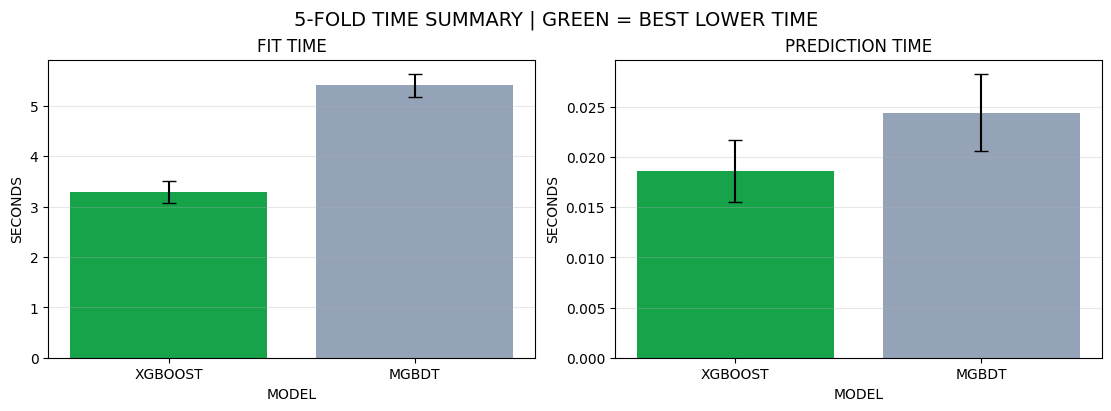

In [11]:
print_context("TIME SUMMARY TABLE AND GRAPH")

def winner_colors(stats, higher_is_better=False):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


time_summary = (
    val_report.groupby("model")[["fit_seconds", "predict_seconds"]]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(time_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, col, title in [
    (axes[0], "fit_seconds", "FIT TIME"),
    (axes[1], "predict_seconds", "PREDICTION TIME"),
]:
    stats = val_report.groupby("model")[col].agg(["mean", "std"]).reindex(MODEL_ORDER)
    colors = winner_colors(stats, higher_is_better=False)
    ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
    ax.set_title(title)
    ax.set_xlabel("MODEL")
    ax.set_ylabel("SECONDS")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("5-FOLD TIME SUMMARY | GREEN = BEST LOWER TIME", fontsize=14)
plt.show()


[METRIC SUMMARY TABLE AND GRAPH]
DATA CSV: C:\Career\UNIST\4-1\Machine Learning\Project\house-price-regressor\data\processed\usa_housing_dataset_price.csv
TARGET: price
DROP_ADDRESS: False
DROP_COORD: False
FOLDS: 5
MODEL ORDER: ['XGBOOST', 'MGBDT']



MAE                        RMSE                     MAPE  \
                  mean          std           mean           std       mean   
model                                                                         
XGBOOST   93742.607432  4065.084952  177368.735228  17722.513221  18.923358   
MGBDT    115935.251355  7754.671648  220261.840180  21058.489902  22.672631   

                         R2           Adjusted_R2            
              std      mean       std        mean       std  
model                                                        
XGBOOST  1.267977  0.734186  0.051469    0.728532  0.052562  
MGBDT    3.379422  0.591881  0.068686    0.583199  0.070149

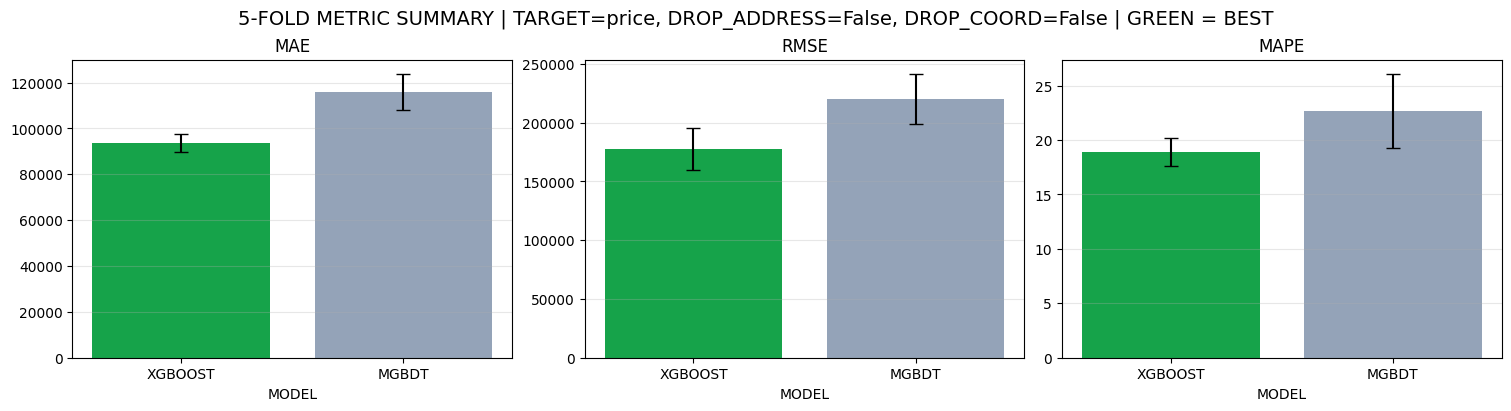

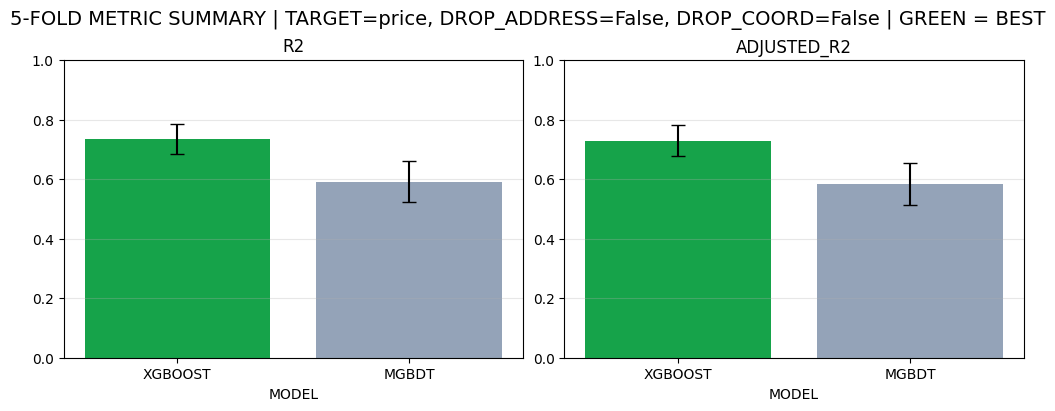

In [12]:
print_context("METRIC SUMMARY TABLE AND GRAPH")

def winner_colors(stats, higher_is_better):
    best_model = stats["mean"].idxmax() if higher_is_better else stats["mean"].idxmin()
    return ["#16a34a" if model == best_model else "#94a3b8" for model in stats.index]


metric_order = ["MAE", "RMSE", "MAPE", "R2", "Adjusted_R2"]
higher_is_better = {
    "MAE": False,
    "RMSE": False,
    "MAPE": False,
    "R2": True,
    "Adjusted_R2": True,
}

metric_summary = (
    val_report.groupby("model")[metric_order]
    .agg(["mean", "std"])
    .reindex(MODEL_ORDER)
)

display(metric_summary)

metric_groups = [
    ["MAE", "RMSE", "MAPE"],
    ["R2", "Adjusted_R2"],
]

for group in metric_groups:
    fig, axes = plt.subplots(1, len(group), figsize=(5 * len(group), 4), constrained_layout=True)
    if len(group) == 1:
        axes = [axes]
    for ax, metric in zip(axes, group):
        stats = val_report.groupby("model")[metric].agg(["mean", "std"]).reindex(MODEL_ORDER)
        colors = winner_colors(stats, higher_is_better=higher_is_better[metric])
        ax.bar(stats.index, stats["mean"], yerr=stats["std"], capsize=5, color=colors)
        ax.set_title(metric.upper())
        ax.set_xlabel("MODEL")
        ax.grid(axis="y", alpha=0.3)
        if metric in {"R2", "Adjusted_R2"}:
            low = min(0, float((stats["mean"].fillna(0)).min()) - 0.05)
            ax.set_ylim(low, 1.0)

    fig.suptitle(
        f"5-FOLD METRIC SUMMARY | TARGET={TARGET_NAME}, "
        f"DROP_ADDRESS={DROP_ADDRESS}, DROP_COORD={DROP_COORD} | GREEN = BEST",
        fontsize=14,
    )
    plt.show()
